# Multiple Linear Regression — Vehicle CO₂ Prediction
### Enhanced Jupyter practical · OMC9000UK7 · MSc Artificial Intelligence and Machine Learning
**Gulf College · AY 2026–2027 · Lecture 4 concepts / Lecture 5 regression bridge**

**Teaching progression:** simple intuition → inspect original data → clean carefully → draw distributions → train a simple baseline → fit multiple linear regression → evaluate unseen vehicles → interpret coefficients → predict new inputs → discuss limitations.

**Learning connections:**
- **MLO1:** recognise applications of AI/ML models;
- **MLO3:** apply a suitable ML technique in a software environment;
- **MLO4 (extension):** compare models and justify the selection for the task.

**Important:** The supplied CO₂ values have no explicitly stated measurement unit or data provenance. We call them **recorded CO₂ values** rather than assuming a unit or claiming that any prediction is a certified emissions measurement. Results are for teaching, not vehicle purchasing, regulation or environmental compliance.

**Files:** `CO2_sum_original.csv` (unchanged), `CO2_cleaned_all_records.csv` (cleaned, all rows), `CO2_modeling_unique.csv` (duplicate-free modelling table), `CO2_new_vehicle_scenarios.csv` (fictional inputs without labels). Run the notebook from the same folder.

## 1. The problem: predict a number rather than a class
A vehicle has measurable characteristics such as **engine displacement** and **number of cylinders**. We want to estimate a numerical outcome: its recorded CO₂ value.

This is **supervised regression**, because each training record has inputs and a known numerical target.

| Component | This example |
|---|---|
| Observation | One vehicle record |
| Feature X₁ | Engine size (`eng_size`) |
| Feature X₂ | Cylinder count (`cylinders`) |
| Target y | Recorded CO₂ value (`co2`) |
| Model output | A number, not a category |

**Why multiple regression?** Ordinary simple linear regression uses one feature. Multiple linear regression uses two or more features to predict one numerical target.

\[\widehat{CO_2}=b_0+b_1\times\mathrm{engine\ size}+b_2\times\mathrm{cylinders}\]

*Discussion:* What additional available-before-prediction factors (vehicle mass, fuel type, transmission, driving cycle) might influence emissions? They are **not present in this dataset**, so we must not invent them as known features.

In [1]:
# Cell 1: imports — install packages with: pip install -r requirements.txt
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = Path('.')
SEED = 42
print('Ready to analyse vehicle CO2 data')

Ready to analyse vehicle CO2 data


## 2. Begin with the original dataset, not a simulated replacement
The original file is preserved unchanged. First inspect its columns, the number of records and the first few vehicles. This is an important part of the ML workflow: **understand the data before fitting the model**.

In [2]:
raw = pd.read_csv(DATA_DIR / 'CO2_sum_original.csv')
print('Original shape:', raw.shape)
print('Original columns:', list(raw.columns))
print(raw.head(8).to_string(index=False))
print('Missing values:', raw.isna().sum().to_dict())
print('Exact duplicate rows:', int(raw.duplicated().sum()))

Original shape: (1022, 5)
Original columns: ['make', 'model', 'eng_size', 'cylender', 'co2']
 make      model  eng_size  cylender  co2
ACURA        ILX       2.0         4  196
ACURA        ILX       2.4         4  221
ACURA ILX HYBRID       1.5         4  136
ACURA        TSX       2.4         4  212
ACURA        TSX       2.4         4  225
ACURA        TSX       3.5         6  239
 AUDI         A4       2.0         4  202
 AUDI A4 QUATTRO       2.0         4  230
Missing values: {'make': 0, 'model': 0, 'eng_size': 0, 'cylender': 0, 'co2': 0}
Exact duplicate rows: 215


### 2.1 Why the original data needs careful cleaning
The source field is spelled `cylender` and is renamed `cylinders` for clarity. Manufacturer/model names are stripped and standardised. An exact duplicate may reflect a repeated source row **or** genuinely duplicated vehicle specifications; its meaning cannot be proven without provenance. Therefore, we keep **all source rows** in one file and use a deduplicated version for the instructional modelling exercise to reduce duplicate leakage between training and testing.

We do **not** make up CO₂ labels or claim that additional simulated vehicles have measured emissions.

**Data-quality observation:** The raw CSV contains 215 exact duplicate rows. After normalising whitespace in manufacturer and model names, additional duplicates are identifiable. The deduplicated modelling table contains 782 vehicle records. This does not prove that the repeated source rows are errors.


In [3]:
cleaned = raw.rename(columns={'cylender':'cylinders'}).copy()
for column in ['make','model']:
    cleaned[column] = (cleaned[column].astype(str).str.strip().str.upper()
                       .str.replace(r'\s+', ' ', regex=True))
cleaned.insert(0, 'source_row', np.arange(1, len(cleaned) + 1))
source_fields = ['make', 'model', 'eng_size', 'cylinders', 'co2']
cleaned['duplicate_exact'] = cleaned.duplicated(subset=source_fields)
cleaned['vehicle_family'] = cleaned['make'] + ' | ' + cleaned['model']
cleaned['engine_per_cylinder'] = (cleaned.eng_size / cleaned.cylinders).round(3)
cleaned.to_csv('CO2_cleaned_all_records.csv', index=False)
df = cleaned.loc[~cleaned.duplicate_exact].copy().reset_index(drop=True)
df.to_csv('CO2_modeling_unique.csv', index=False)
print('Source rows:', len(cleaned), '| flagged duplicate rows:', cleaned.duplicate_exact.sum())
print('Unique modelling rows:', len(df), '| Makes:', df.make.nunique(), '| Vehicle families:', df.vehicle_family.nunique())
print(df[['make','model','eng_size','cylinders','co2']].head().to_string(index=False))

Source rows: 1022 | flagged duplicate rows: 240
Unique modelling rows: 782 | Makes: 27 | Vehicle families: 236
 make      model  eng_size  cylinders  co2
ACURA        ILX       2.0          4  196
ACURA        ILX       2.4          4  221
ACURA ILX HYBRID       1.5          4  136
ACURA        TSX       2.4          4  212
ACURA        TSX       2.4          4  225


## 3. Exploratory data analysis: draw the actual observations
Visualising the training data helps answer:
1. Is a larger engine **associated** with higher CO₂ values?
2. Do vehicles with the same engine size have different CO₂ outcomes?
3. Are engine size and cylinder count themselves highly related?

These plots do not establish causation.

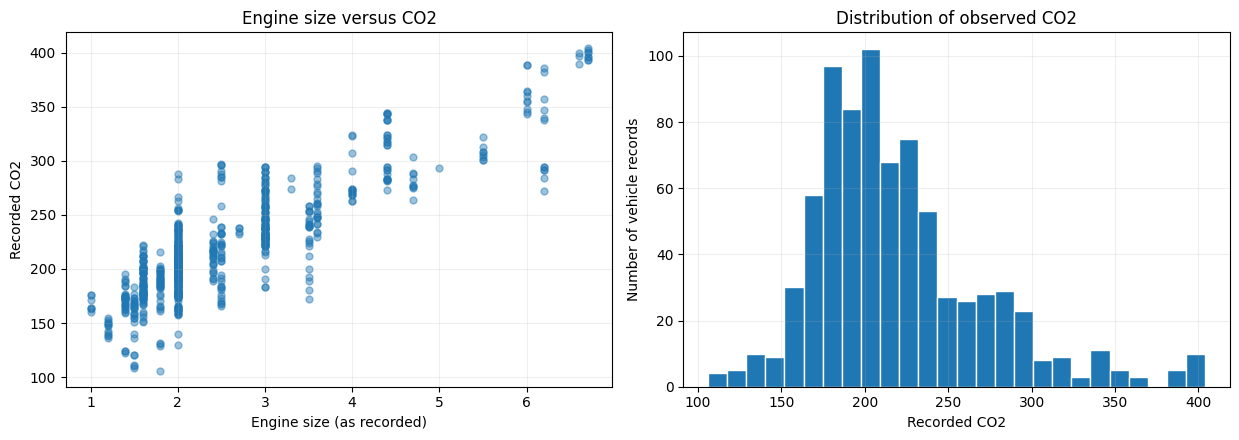

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5,4.5))
axes[0].scatter(df.eng_size, df.co2, alpha=.45, s=25)
axes[0].set(xlabel='Engine size (as recorded)', ylabel='Recorded CO2', title='Engine size versus CO2')
axes[0].grid(alpha=.2)
axes[1].hist(df.co2, bins=26, edgecolor='white')
axes[1].set(xlabel='Recorded CO2', ylabel='Number of vehicle records', title='Distribution of observed CO2')
axes[1].grid(alpha=.2)
plt.tight_layout();plt.savefig('01_Explore_Engine_CO2.png',dpi=145);plt.show()

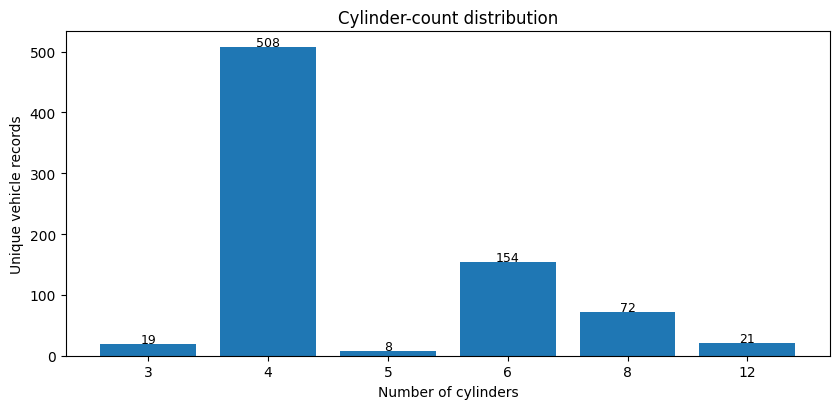

Correlation matrix:
            eng_size  cylinders    co2
eng_size      1.000      0.945  0.870
cylinders     0.945      1.000  0.847
co2           0.870      0.847  1.000


In [5]:
# Bar chart: how many unique vehicles are in each cylinder group?
counts = df.cylinders.value_counts().sort_index()
plt.figure(figsize=(8.5,4.2))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel('Number of cylinders');plt.ylabel('Unique vehicle records')
plt.title('Cylinder-count distribution')
for i, value in enumerate(counts.values):plt.text(i,value+2,str(value),ha='center',fontsize=9)
plt.tight_layout();plt.savefig('02_Cylinder_Distribution.png',dpi=145);plt.show()
print('Correlation matrix:\n', df[['eng_size','cylinders','co2']].corr().round(3).to_string())

### 3.1 Correlation warning
Engine size and cylinder count are strongly correlated in this dataset. Both may be useful predictors, but their regression coefficients can become sensitive to the exact training sample. This is called **multicollinearity**.

It does **not** mean that the model cannot predict well. It means a coefficient should not automatically be interpreted as a causal change produced by changing just that variable. Compare predictive performance as well as interpretability.

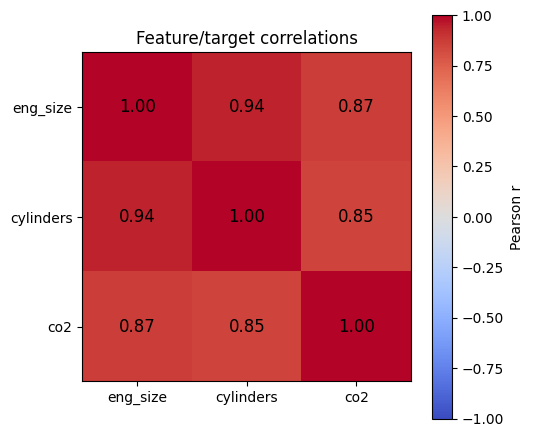

In [6]:
variables = ['eng_size','cylinders','co2']
corr = df[variables].corr()
fig,ax=plt.subplots(figsize=(5.4,4.6))
im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm')
ax.set_xticks(range(len(variables)),variables);ax.set_yticks(range(len(variables)),variables)
for i in range(len(variables)):
 for j in range(len(variables)):
  ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',color='black',fontsize=12)
ax.set_title('Feature/target correlations');fig.colorbar(im,ax=ax,label='Pearson r')
plt.tight_layout();plt.savefig('03_Correlation_Heatmap.png',dpi=145);plt.show()

## 4. Prepare a genuine held-out test set
We should not evaluate the model only on the records used to fit it. Furthermore, multiple rows share the same `make` and `model`. To provide a more challenging and useful demonstration, we reserve **entire make/model families** for the test set using `GroupShuffleSplit`. This tests generalisation to **unseen model families**, not just another duplicate record.

We retain about 80% of the groups for training and 20% for testing. The actual proportion of rows may differ because vehicle families have different sizes. This is a stricter test than a naïve random split. We keep `make`/`model` **only for grouping**; the basic prediction model uses engine size and cylinders.

In [7]:
features = ['eng_size','cylinders']
X = df[features]
y = df['co2']
groups = df['vehicle_family']
splitter = GroupShuffleSplit(n_splits=1, test_size=.20, random_state=SEED)
train_ids, test_ids = next(splitter.split(X,y,groups=groups))
X_train, X_test = X.iloc[train_ids], X.iloc[test_ids]
y_train, y_test = y.iloc[train_ids], y.iloc[test_ids]
train_families=set(groups.iloc[train_ids]);test_families=set(groups.iloc[test_ids])
assert train_families.isdisjoint(test_families)
print('Training rows:',len(X_train),'Test rows:',len(X_test))
print('Training families:',len(train_families),'Test families:',len(test_families))
print('Family overlap:',len(train_families & test_families))

Training rows: 635 Test rows: 147
Training families: 188 Test families: 48
Family overlap: 0


## 5. Train four simple models to make comparison meaningful
A model is not good merely because a graph looks close. We compare these established alternatives:
1. **Mean baseline**: always predicts the mean of the training target (no relationship learnt).
2. **Simple linear regression**: uses engine size alone.
3. **Multiple linear regression**: uses engine size **and** cylinder count — the main method of this notebook.
4. **Ridge regression**: an optional comparison that regularises coefficients when predictors are correlated.

Only the training portion is used to fit the models. All models are evaluated on the **same unseen test set**.

In [8]:
models = {
    'Mean baseline': DummyRegressor(strategy='mean'),
    'Simple: engine only': LinearRegression(),
    'Multiple: engine + cylinders': LinearRegression(),
    'Ridge: engine + cylinders': Ridge(alpha=10)
}
columns_by_model = {
    'Mean baseline': ['eng_size'],
    'Simple: engine only': ['eng_size'],
    'Multiple: engine + cylinders': features,
    'Ridge: engine + cylinders': features
}
rows=[]
for name, model in models.items():
    cols=columns_by_model[name]
    model.fit(X_train[cols], y_train)
    pred=model.predict(X_test[cols])
    rows.append({'Model':name,'MAE':mean_absolute_error(y_test,pred),
                 'RMSE':np.sqrt(mean_squared_error(y_test,pred)),
                 'R2':r2_score(y_test,pred)})
metrics=pd.DataFrame(rows).sort_values('MAE')
metrics.to_csv('model_comparison_metrics.csv',index=False)
print(metrics.round(3).to_string(index=False))

                       Model    MAE   RMSE     R2
Multiple: engine + cylinders 15.274 21.192  0.873
   Ridge: engine + cylinders 15.285 21.176  0.873
         Simple: engine only 15.961 21.924  0.864
               Mean baseline 42.393 60.044 -0.018


## 6. What do MAE, RMSE and R² tell us?
- **MAE — Mean Absolute Error:** average size of a prediction error in the target's recorded units. Smaller is better.
- **RMSE — Root Mean Squared Error:** gives larger mistakes more influence. Smaller is better.
- **R² — Coefficient of determination:** improvement in squared-error fit relative to always predicting the **test-set mean**; 1 is perfect, 0 matches that baseline, and negative values are possible. Larger is better.

For regression, classification accuracy, precision, recall and a confusion matrix are **not the primary metrics** because the target is numeric rather than a discrete class. One can turn outcomes into bins, but that changes the task.

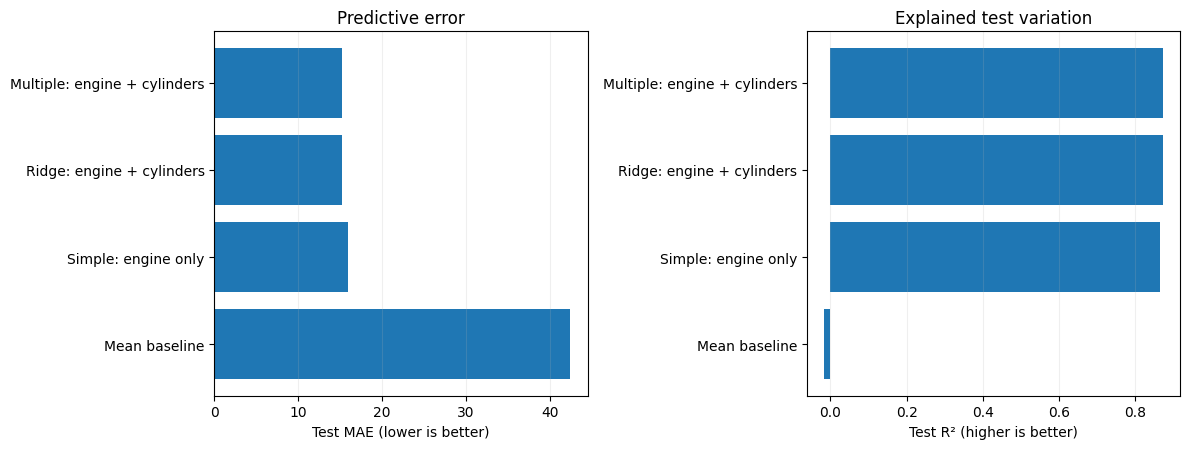

In [9]:
fig,axes=plt.subplots(1,2,figsize=(12,4.6))
items=metrics['Model'].tolist()
axes[0].barh(items,metrics.MAE)
axes[0].invert_yaxis();axes[0].set(xlabel='Test MAE (lower is better)',title='Predictive error')
axes[1].barh(items,metrics.R2)
axes[1].invert_yaxis();axes[1].set(xlabel='Test R² (higher is better)',title='Explained test variation')
for ax in axes:ax.grid(axis='x',alpha=.2)
plt.tight_layout();plt.savefig('04_Model_Comparison.png',dpi=145);plt.show()

## 7. Read the learned equation: this is the central multiple-regression result
The computer estimates three numbers using training data:

\[\widehat{CO_2}=b_0+b_1\times\texttt{eng_size}+b_2\times\texttt{cylinders}\]

- `b0` is the **intercept** (a mathematical parameter, not necessarily a realistic zero-engine vehicle).
- `b1` is the association with a one-unit change in engine size **holding cylinders fixed**.
- `b2` is the association with one additional cylinder **holding engine size fixed**.

Because the input features are strongly associated with one another, these conditional associations can be unstable. Do not interpret them as experimental causal effects.

In [10]:
reg=models['Multiple: engine + cylinders']
intercept=reg.intercept_
coef_engine,coef_cyl=reg.coef_
print(f'Intercept b0: {intercept:.4f}')
print(f'Engine size coefficient b1: {coef_engine:.4f}')
print(f'Cylinders coefficient b2: {coef_cyl:.4f}')
print(f'Fitted equation: CO2_hat = {intercept:.3f} + ({coef_engine:.3f} × engine_size) + ({coef_cyl:.3f} × cylinders)')
coefficients=pd.DataFrame({'term':['Intercept','Engine size','Cylinders'],
'coefficient':[intercept,coef_engine,coef_cyl]})
coefficients.to_csv('regression_coefficients.csv',index=False)

Intercept b0: 113.8237
Engine size coefficient b1: 28.9041
Cylinders coefficient b2: 6.4750
Fitted equation: CO2_hat = 113.824 + (28.904 × engine_size) + (6.475 × cylinders)


### 7.1 Calculate one prediction manually
Take a hypothetical vehicle with **engine size 2.3** and **4 cylinders**. Put its values into the learned equation:

\[\widehat{CO_2}=b_0+2.3b_1+4b_2\]

Check that your arithmetic matches `model.predict`. This is the simplest way to connect the equation to code.

In [11]:
manual=intercept+coef_engine*2.3+coef_cyl*4
example=pd.DataFrame({'eng_size':[2.3],'cylinders':[4]})
automatic=reg.predict(example)[0]
print('Manual calculation:',round(manual,2))
print('scikit-learn prediction:',round(automatic,2))
assert np.isclose(manual,automatic)

Manual calculation: 206.2
scikit-learn prediction: 206.2


## 8. Visually evaluate generalisation
The **observed-versus-predicted** graph compares test observations with model estimates. Points on the diagonal are perfect predictions. We also plot **residuals** (actual minus predicted). Random scatter is generally more reassuring than a clear curved or funnel-shaped pattern.

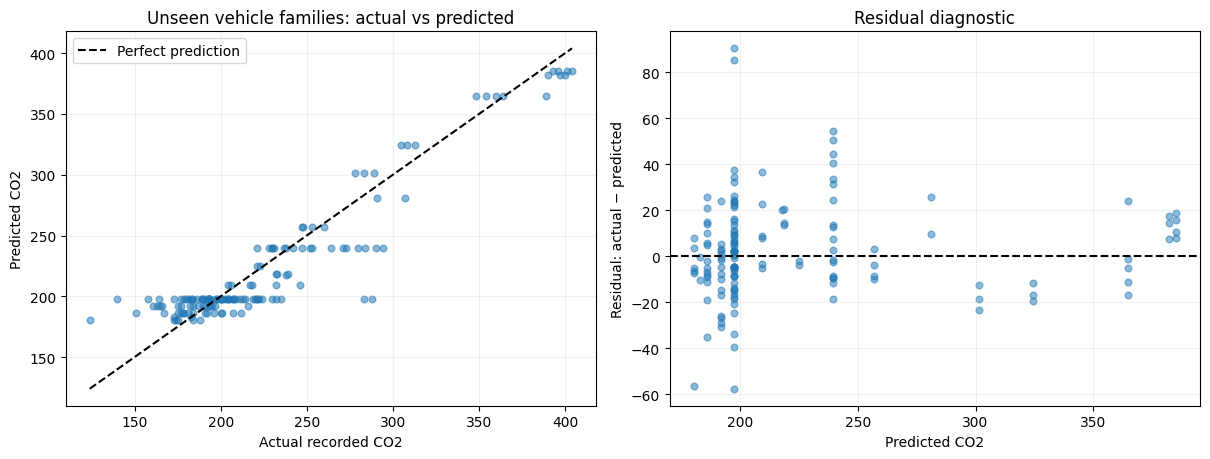

make      model  eng_size  cylinders  co2  predicted_co2  error_actual_minus_predicted
AUDI A4 QUATTRO       2.0          4  230        197.532                        32.468
AUDI A4 QUATTRO       2.0          4  214        197.532                        16.468
 BMW       320I       2.0          4  193        197.532                        -4.532
 BMW       320I       2.0          4  200        197.532                         2.468
 BMW       328I       2.0          4  193        197.532                        -4.532
 BMW       328I       2.0          4  200        197.532                         2.468
 BMW       335I       3.0          6  221        239.386                       -18.386
 BMW       335I       3.0          6  230        239.386                        -9.386


In [12]:
forecast=reg.predict(X_test[features])
residual=y_test.to_numpy()-forecast
fig,axes=plt.subplots(1,2,figsize=(12.2,4.7))
axes[0].scatter(y_test,forecast,alpha=.52,s=23)
lo=min(y_test.min(),forecast.min());hi=max(y_test.max(),forecast.max())
axes[0].plot([lo,hi],[lo,hi],ls='--',color='black',label='Perfect prediction')
axes[0].set(xlabel='Actual recorded CO2',ylabel='Predicted CO2',title='Unseen vehicle families: actual vs predicted')
axes[0].legend()
axes[1].scatter(forecast,residual,alpha=.5,s=23)
axes[1].axhline(0,ls='--',color='black')
axes[1].set(xlabel='Predicted CO2',ylabel='Residual: actual − predicted',title='Residual diagnostic')
for ax in axes:ax.grid(alpha=.17)
plt.tight_layout();plt.savefig('05_Actual_Predicted_Residuals.png',dpi=145);plt.show()
results=df.iloc[test_ids][['make','model','eng_size','cylinders','co2']].copy()
results['predicted_co2']=np.round(forecast,3)
results['error_actual_minus_predicted']=np.round(residual,3)
results.to_csv('unseen_test_predictions.csv',index=False)
print(results.head(8).to_string(index=False))

## 9. More responsible validation: GroupKFold cross-validation
A single train/test split can be lucky or unlucky. Cross-validation evaluates the method repeatedly on **different unseen vehicle families**. We still avoid mixing the same make/model group between training and validation folds.

We calculate five cross-validated MAEs on the modelling dataset using the same two-feature linear model. These scores help us describe the uncertainty arising from the chosen sample split; they are not a statistical confidence interval.

5 grouped validation MAEs: [17.   23.26 23.21 17.05 14.55]
Mean MAE: 19.01 | Std: 3.56


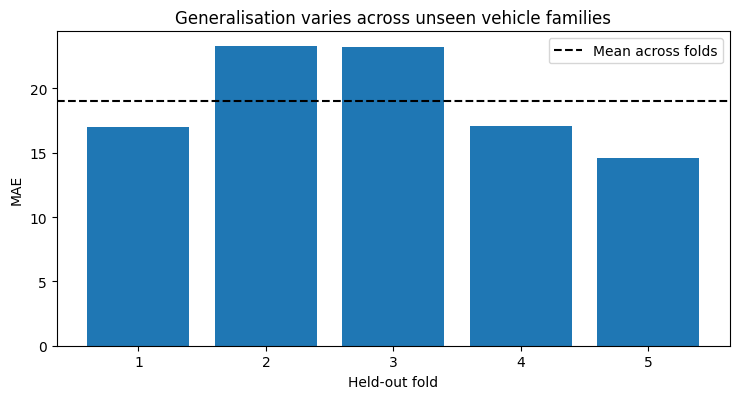

In [13]:
cv=GroupKFold(n_splits=5)
fold_mae=-cross_val_score(LinearRegression(),X,y,groups=groups,
                         scoring='neg_mean_absolute_error',cv=cv)
print('5 grouped validation MAEs:',np.round(fold_mae,2))
print('Mean MAE:',round(fold_mae.mean(),2),'| Std:',round(fold_mae.std(),2))
plt.figure(figsize=(7.5,4.1))
plt.bar(np.arange(1,6).astype(str),fold_mae)
plt.axhline(fold_mae.mean(),linestyle='--',color='black',label='Mean across folds')
plt.xlabel('Held-out fold');plt.ylabel('MAE');plt.title('Generalisation varies across unseen vehicle families')
plt.legend();plt.tight_layout();plt.savefig('06_Group_Cross_Validation.png',dpi=145);plt.show()

## 10. Use the fitted model for completely new values
The following **scenario inputs are fictional** and are *not additional training records*. There are no known measured CO₂ labels for these scenarios. The model will return **estimates**, not proven outcomes.

It is better to use a DataFrame with the **same column names** as training, to avoid feature-order mistakes. Interpret predictions only for reasonable input combinations within the studied data range.

                        scenario  eng_size  cylinders  estimated_co2
                Compact city car       1.2          4          174.4
                Small family car       1.6          4          186.0
             Mid-size family car       2.0          4          197.5
        Mid-size higher-cylinder       2.5          6          224.9
                     SUV example       3.0          6          239.4
                Large-engine car       4.0          8          281.2
        Three-cylinder small car       1.0          3          162.2
         Six-cylinder family car       3.5          6          253.8
Four-cylinder turbo-size example       2.3          4          206.2
                 Upper range car       5.0          8          310.1


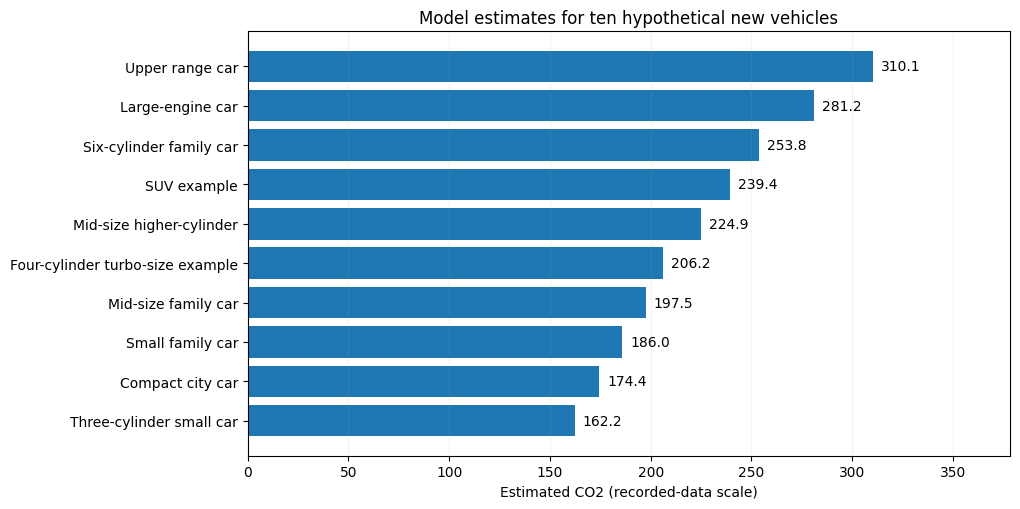

In [14]:
scenarios = pd.read_csv('CO2_new_vehicle_scenarios.csv')
scenarios['estimated_co2'] = np.round(reg.predict(scenarios[features]), 1)
scenarios.to_csv('CO2_scenario_predictions.csv', index=False)
print(scenarios.to_string(index=False))

# Horizontal bars make the ten new predictions readable without overlapping labels.
ordered = scenarios.sort_values('estimated_co2')
fig, ax = plt.subplots(figsize=(10.3, 5.2))
bars = ax.barh(ordered['scenario'], ordered['estimated_co2'])
ax.set(xlabel='Estimated CO2 (recorded-data scale)',
       title='Model estimates for ten hypothetical new vehicles')
ax.set_xlim(0, max(ordered.estimated_co2) * 1.22)
for bar, value in zip(bars, ordered['estimated_co2']):
    ax.text(bar.get_width()+4,bar.get_y()+bar.get_height()/2, f'{value:.1f}',va='center')
ax.grid(axis='x',alpha=.15)
plt.tight_layout()
plt.savefig('07_New_Scenarios.png', dpi=145)
plt.show()

## 11. A new vehicle of your own: change these two numbers
Try the example with `engine_size=2.8` and `number_of_cylinders=6`. Change the values after running the cell, then explain the result as an **estimate**, not a measurement. No retraining is required for new predictions.

In [15]:
engine_size=2.8        # Student: change this value
number_of_cylinders=6  # Student: change this value
my_vehicle=pd.DataFrame({'eng_size':[engine_size],'cylinders':[number_of_cylinders]})
print(f'Estimated CO2 for engine={engine_size}, cylinders={number_of_cylinders}:',
      round(reg.predict(my_vehicle)[0],2))

Estimated CO2 for engine=2.8, cylinders=6: 233.61


## 12. Important limitations and misconceptions
1. **Predictive association is not causation.** Neither the linear model nor the dataset proves that altering cylinder count by one will change emissions by exactly `b2`.
2. **Missing important inputs:** Vehicle mass, fuel technology, transmission, driving cycle and powertrain details are absent. The model cannot control for them.
3. **No verified provenance or units:** The original source does not provide a formal unit, origin, test protocol or date.
4. **Repeated records:** Exact duplicate data can bias evaluation if the same records are split into train/test. We retained a complete cleaned copy and used unique records for the example; true duplicate meaning is unknown.
5. **Correlated predictors:** Engine size and cylinders are strongly related; coefficients should be interpreted carefully.
6. **No classification confusion matrix:** The target is a number. If a class such as High/Low emissions were defined, that would be a different classification problem requiring a justified threshold.
7. **Generalisation matters:** Performance on unseen model families is more informative here than training-set performance.
8. **Model estimates are not recommendations:** This simplified model should not be used for compliance or real purchasing decisions.

## 13. Exercises for MSc students
**Exercise 1 (concept):** Identify one feature, the target, and one potential source of data leakage.

**Exercise 2 (manual):** Use the printed coefficients to calculate a prediction for 1.8 engine size and four cylinders. Verify it in Python.

**Exercise 3 (visual):** Which scatterplot pattern suggests a linear relationship? Where do outliers appear?

**Exercise 4 (metrics):** Explain in one sentence each what MAE, RMSE and R² measure. Which of these has the same unit as the target?

**Exercise 5 (experimental):** Remove the `cylinders` feature and compare test-set MAE. Did the extra feature improve unseen predictions on this split?

**Exercise 6 (critical reasoning):** Why might the learned cylinder coefficient be surprising when engine size is included?

**Exercise 7 (validation):** Why does it matter that no vehicle family occurs in both training and test sets?

**Exercise 8 (application):** Create two new hypothetical vehicles, estimate CO₂, and explain why the estimates could be inaccurate in practice.

**Exercise 9 (advanced):** Contrast the multiple linear and Ridge coefficients. Does regularisation necessarily make the predictions better?

**Exercise 10 (assessment preparation):** Explain how this notebook follows the sequence: problem → data → representation → training → evaluation → justified use.

**Expected learning:** Describe, apply and critically evaluate multiple linear regression in a reproducible Jupyter environment.

## References and reading
- Russell, S., Norvig, P., and Chang, M.-W. (2021). *Artificial Intelligence: A Modern Approach*, 4th ed., Pearson.
- James, G., Witten, D., Hastie, T., and Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. https://www.statlearning.com/
- scikit-learn developers. *Linear Models, Cross-validation and Model Evaluation*. https://scikit-learn.org/stable/user_guide.html
- Uploaded original data: `CO2_sum.csv` and lecturer notebook `multiple linear regression.ipynb`, preserved in this teaching package. Dataset provenance and CO₂ unit were not provided.

*Reminder:* If using this example for research or professional purposes, replace the data with a verified source, define emissions units/protocol, include important features, document sampling, and evaluate on a truly representative deployment population.